# Topic Modeling: Public Reaction to AI-Related Short-Form Video Content
**Data:** YouTube and TikTok comments | **Models:** LDA (gensim) and BERTopic | **Metrics:** c_v, u_mass, held-out perplexity, topic diversity

Pipeline: load, filter, preprocess, explore, 90/10 split, LDA (choose k by coherence), evaluate, visualize, BERTopic, compare, topic-by-platform.

In [2]:
# !pip install matplotlib scikit-learn langdetect pyLDAvis bertopic sentence-transformers umap-learn hdbscan
# gensim has no Python 3.14 wheel on PyPI yet, so install it from git (builds cleanly with Cython):
# !pip install git+https://github.com/RaRe-Technologies/gensim.git

## 1. Imports and settings

In [1]:
import json, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from langdetect import detect, DetectorFactory
from sklearn.model_selection import train_test_split
from gensim.corpora import Dictionary
from gensim.models import LdaModel, CoherenceModel
from gensim.models.phrases import Phrases

warnings.filterwarnings("ignore")
SEED = 42
DetectorFactory.seed = SEED
DATA_PATH = "preprocessed_dataset.json"
MAX_PER_VIDEO = 100      # cap so no single video dominates the topics
MIN_TOKENS = 3           # minimum tokens per comment after cleaning

## 2. Load data

In [2]:
with open(DATA_PATH, encoding="utf-8") as f:
    raw = json.load(f)
df = pd.DataFrame(raw["documents"])
print("Loaded:", df.shape)
print(df["platform"].value_counts())
df[["platform", "original_text", "clean_text"]].head()

Loaded: (6554, 14)
platform
TikTok     5522
YouTube    1032
Name: count, dtype: int64


,platform,original_text,clean_text
0,YouTube,Finaly a straight to the point shortfilm. No d...,finaly straight point shortfilm dragged dialogues
1,YouTube,For real I hate that shit lol,real hate shit lol
2,YouTube,I conquer,conquer
3,YouTube,Aw he loved her before she lost weight,loved lost weight
4,YouTube,Am just loving the wife and also how she prote...,loving wife also protect kids like also treate...


## 3. Filtering
Steps: drop duplicate comments, drop very short comments, keep English/Tagalog only (the TikTok data contains a lot of Italian), cap comments per video.

In [3]:
n0 = len(df)
df = df.drop_duplicates("clean_text")
df = df[df["clean_text"].str.split().str.len() >= MIN_TOKENS]
n1 = len(df)

def lang(t):
    try:
        return detect(t)
    except Exception:
        return "unk"

df["lang"] = df["original_text"].apply(lang)
print(df["lang"].value_counts().head(8))
df = df[df["lang"].isin(["en", "tl"])]
n2 = len(df)

df = (df.sample(frac=1, random_state=SEED)            # shuffle, then keep up to N per video
        .groupby("content_id").head(MAX_PER_VIDEO)
        .reset_index(drop=True))
n3 = len(df)

pd.DataFrame({"step": ["start", "dedupe + min tokens", "English/Tagalog only", "cap per video"],
              "rows": [n0, n1, n2, n3]})

lang
en    1633
it    1132
id      60
da      51
fr      49
tl      44
so      33
pt      33
Name: count, dtype: int64


,step,rows
0,start,6554
1,dedupe + min tokens,3302
2,English/Tagalog only,1677
3,cap per video,1357


## 4. Preprocessing for topic modeling 
Here we remove domain stopwords (filler such as "next part please") and tokenize.

In [4]:
STOP = {
    # AI terms that appear everywhere
    "ai", "artificial", "intelligence", "chatgpt", "gpt",
    # platform and request filler
    "next", "part", "episode", "please", "pls", "plz", "movie", "channel", "subscribe",
    "thank", "thanks", "watch", "watching", "watched", "full", "drama", "video", "videos",
    "like", "just", "really", "one", "get", "can", "don", "will", "now", "make", "made",
    # common Taglish fillers
    "ang", "ng", "na", "sa", "mga", "po", "ako", "ka", "ko", "naman", "lang", "yung",
    "din", "ba", "pa", "kasi", "talaga",
    # emoji names, platform names and Pidgin fillers seen in the data
    "red", "heart", "joy", "face", "tiktok", "instagram", "facebook", "youtube",
    "https", "www", "dey", "abeg",
}

def tokenize(text):
    return [w for w in re.findall(r"[a-z']+", text.lower()) if w not in STOP and len(w) > 2]

df["tokens"] = df["clean_text"].apply(tokenize)
df = df[df["tokens"].str.len() >= 2].reset_index(drop=True)
print("Rows after stopword removal:", len(df))
df[["clean_text", "tokens"]].head()

Rows after stopword removal: 1291


,clean_text,tokens
0,even laughing anymore tears montoya por favor,"[even, laughing, anymore, tears, montoya, por,..."
1,blonde chick always shouting mean parents,"[blonde, chick, always, shouting, mean, parents]"
2,gods mortal want,"[gods, mortal, want]"
3,thank drama please post rest,"[post, rest]"
4,love temper heartwarming,"[love, temper, heartwarming]"


## 5. Data exploration

           count  mean  std  min  25%  50%  75%    max
platform                                              
TikTok    1005.0   5.1  4.0  2.0  3.0  4.0  6.0   57.0
YouTube    286.0   6.7  9.1  2.0  3.0  4.0  7.0  126.0

Comments per video (top 5):
content_id
7482999322599181614    99
n9D3b0K9pko            96
7469458353190636805    92
7686339862995291422    87
7676528108995972374    82
dtype: int64


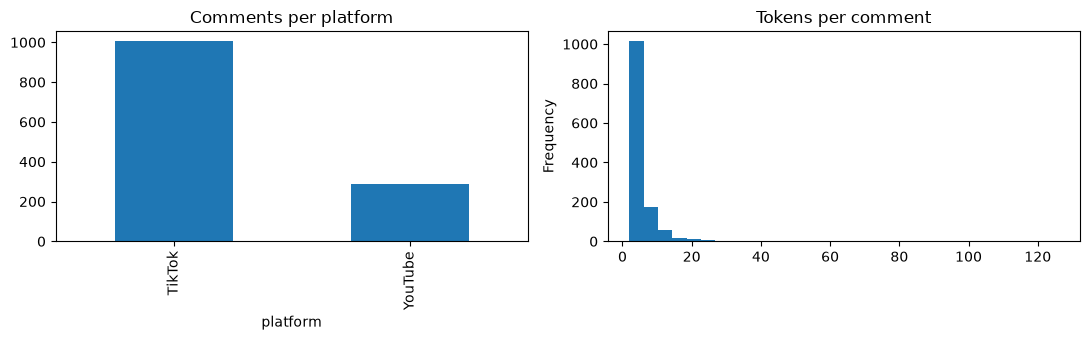

TikTok [('back', 54), ('love', 52), ('man', 45), ('bring', 39), ('story', 37), ('know', 36), ('people', 34), ('want', 31), ('see', 29), ('girl', 27), ('even', 26), ('tears', 26), ('good', 25), ('someone', 25), ('always', 25)]
YouTube [('even', 25), ('love', 23), ('story', 21), ('good', 20), ('god', 14), ('lol', 13), ('much', 12), ('interesting', 12), ('rest', 11), ('time', 10), ('well', 10), ('every', 9), ('way', 9), ('people', 9), ('loved', 9)]


In [5]:
df["n_tokens"] = df["tokens"].str.len()
print(df.groupby("platform")["n_tokens"].describe().round(1))
print("\nComments per video (top 5):")
print(df.groupby("content_id").size().sort_values(ascending=False).head())

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
df["platform"].value_counts().plot.bar(ax=ax[0], title="Comments per platform")
df["n_tokens"].plot.hist(bins=30, ax=ax[1], title="Tokens per comment")
plt.tight_layout(); plt.show()

from collections import Counter
for p in df["platform"].unique():
    c = Counter(w for t in df[df.platform == p]["tokens"] for w in t)
    print(p, c.most_common(15))

## 6. Train/holdout split (90/10)
The 10% holdout is unseen data for validation; it is also used for held-out perplexity.

In [6]:
train_df, hold_df = train_test_split(df, test_size=0.10, random_state=SEED, stratify=df["platform"])
train_df, hold_df = train_df.reset_index(drop=True), hold_df.reset_index(drop=True)
print("Train:", len(train_df), "| Holdout:", len(hold_df))

Train: 1161 | Holdout: 130


## 7. Bigrams, dictionary, corpus

In [7]:
train_tokens = train_df["tokens"].tolist()
hold_tokens = hold_df["tokens"].tolist()

bigram = Phrases(train_tokens, min_count=3, threshold=10).freeze()
train_tokens = [bigram[d] for d in train_tokens]
hold_tokens = [bigram[d] for d in hold_tokens]

dictionary = Dictionary(train_tokens)
dictionary.filter_extremes(no_below=2, no_above=0.6)
train_corpus = [dictionary.doc2bow(d) for d in train_tokens]
hold_corpus = [dictionary.doc2bow(d) for d in hold_tokens]
print("Vocabulary size:", len(dictionary))

Vocabulary size: 908


## 8. Choose the number of topics (k) by c_v coherence

3 0.5053
4 0.5109
5 0.4885
6 0.5349
7 0.5675
8 0.5459
9 0.5736
10 0.5778


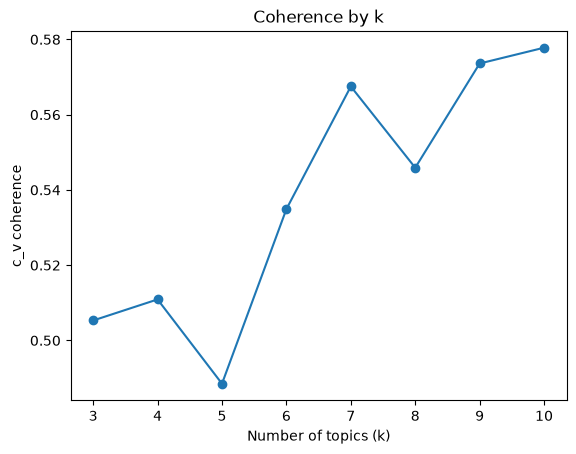

,k,c_v
0,3,0.5053
1,4,0.5109
2,5,0.4885
3,6,0.5349
4,7,0.5675
5,8,0.5459
6,9,0.5736
7,10,0.5778


In [8]:
ks = list(range(3, 11))
rows = []
for k in ks:
    m = LdaModel(train_corpus, num_topics=k, id2word=dictionary, passes=10,
                 random_state=SEED, alpha="auto", eta="auto")
    cv = CoherenceModel(model=m, texts=train_tokens, dictionary=dictionary, coherence="c_v").get_coherence()
    rows.append({"k": k, "c_v": round(cv, 4)})
    print(k, round(cv, 4))

k_table = pd.DataFrame(rows)
plt.plot(k_table["k"], k_table["c_v"], marker="o")
plt.xlabel("Number of topics (k)"); plt.ylabel("c_v coherence"); plt.title("Coherence by k"); plt.show()
k_table

## 9. Final LDA model

In [9]:
best_k = int(k_table.loc[k_table["c_v"].idxmax(), "k"])
print("Selected k =", best_k)

lda = LdaModel(train_corpus, num_topics=best_k, id2word=dictionary, passes=20,
               random_state=SEED, alpha="auto", eta="auto")
for i in range(best_k):
    print(f"Topic {i}:", ", ".join(w for w, _ in lda.show_topic(i, 10)))

Selected k = 10
Topic 0: name, lol, side, see, good, bro, tears, wait, person, two
Topic 1: see, back, done, people, scene, need, cried, waiting, girls, man
Topic 2: story, beautiful, men, still, cute, true, gay, talking, nice, everyone
Topic 3: actually, know, always, building, anyone, let, episodes, well, great, still
Topic 4: find, look, tag, different, stop, already, lesbian, love, every, yae_yae
Topic 5: god, may, protect, wow, always, yeah, free, complete, believe, god_bless
Topic 6: love, much, came, loved, story, tears_tears, rest, girl, omg, way
Topic 7: even, bring_back, want, never, man, right, water, trust_man, girl, know
Topic 8: story, interesting, people, someone, life, way, happy_birthday, glad, dressing, would
Topic 9: love, good, end, post, new, real, also, felt, sorry, show


## 10. Evaluation (LDA)
Note: gensim's held-out perplexity is an ELBO-based estimate and is unstable on very short comments, so treat c_v as the main metric and report perplexity with that caveat.

In [10]:
cv = CoherenceModel(model=lda, texts=train_tokens, dictionary=dictionary, coherence="c_v").get_coherence()
um = CoherenceModel(model=lda, corpus=train_corpus, dictionary=dictionary, coherence="u_mass").get_coherence()
perp = np.exp2(-lda.log_perplexity(hold_corpus))

top_words = [w for t in range(best_k) for w, _ in lda.show_topic(t, 10)]
diversity = len(set(top_words)) / len(top_words)

lda_eval = pd.DataFrame({
    "Metric": ["c_v coherence (higher better)", "u_mass coherence (closer to 0 better)",
               "Held-out perplexity (lower better)", "Topic diversity (higher better)"],
    "Value": [round(cv, 4), round(um, 4), round(perp, 2), round(diversity, 4)]})
lda_eval

,Metric,Value
0,c_v coherence (higher better),0.5768
1,u_mass coherence (closer to 0 better),-17.2526
2,Held-out perplexity (lower better),71401.7700
3,Topic diversity (higher better),0.8700


## 11. Visualization (pyLDAvis)

In [22]:
import pyLDAvis, pyLDAvis.gensim_models as gm

vis = gm.prepare(lda, train_corpus, dictionary, mds="mmds")   # avoids the PCoA complex-value issue
pyLDAvis.save_html(vis, "lda_vis.html")

## 12. Assign dominant topic to each comment

In [23]:
def dominant_topic(bow):
    dist = lda.get_document_topics(bow, minimum_probability=0)
    return max(dist, key=lambda x: x[1])[0]

train_df["lda_topic"] = [dominant_topic(b) for b in train_corpus]
hold_df["lda_topic"] = [dominant_topic(b) for b in hold_corpus]

topic_table = pd.DataFrame({
    "Topic": range(best_k),
    "Top words": [", ".join(w for w, _ in lda.show_topic(i, 8)) for i in range(best_k)],
    "Train docs": [(train_df["lda_topic"] == i).sum() for i in range(best_k)],
    "Holdout docs": [(hold_df["lda_topic"] == i).sum() for i in range(best_k)],
    "Label (write your own)": [""] * best_k,
})
topic_table["Share of train %"] = (topic_table["Train docs"] / len(train_df) * 100).round(1)
topic_table

,Topic,Top words,Train docs,Holdout docs,Label (write your own),Share of train %
0,0,"name, lol, side, see, good, bro, tears, wait",118,12,,10.2
1,1,"see, back, done, people, scene, need, cried, w...",143,20,,12.3
2,2,"story, beautiful, men, still, cute, true, gay,...",107,12,,9.2
3,3,"actually, know, always, building, anyone, let,...",90,11,,7.8
4,4,"find, look, tag, different, stop, already, les...",97,11,,8.4
5,5,"god, may, protect, wow, always, yeah, free, co...",93,10,,8.0
6,6,"love, much, came, loved, story, tears_tears, r...",109,14,,9.4
7,7,"even, bring_back, want, never, man, right, wat...",166,16,,14.3
8,8,"story, interesting, people, someone, life, way...",114,11,,9.8
9,9,"love, good, end, post, new, real, also, felt",124,13,,10.7


### Example comments per topic (use these to label topics)

In [24]:
for i in range(best_k):
    print(f"\n--- Topic {i} ---")
    for t in train_df[train_df["lda_topic"] == i]["original_text"].head(4):
        print("  -", t[:120].replace("\n", " "))


--- Topic 0 ---
  - Wait he and they kiss omo howw
  - I don't like the fact she had to work on her weight
  - Exactly. Forward i move
  - I'm not even laughing anymore its just tears now Montoya Por Favor ️️️

--- Topic 1 ---
  - someone should please bring me back
  - This scene made me so sad. Because it’s relatable.
  - There is a copycat TikTok out there. I’m not sure if it’s your back up.
  - Gender clothes is a construct. I’ve always just more boyish and I’m a straight person.

--- Topic 2 ---
  - I can’t help guys are gay
  - those are not twin girls my boy. one of them is a dude
  - please make it more longer, because is too short main..
  - So someone who does all these can't take care of you in marriage?? Nawa oo

--- Topic 3 ---
  - ​ @bluepuppystudios3617 well atleast the orcas and the leopard seals are fine. Besides we are fine still
  - Agree why so much shooting it sound like need anger management lmao
  - 25 August 2023 my baby died at 2pm
  - shes still a baby bruh



## 13. Topic distribution by platform

platform   TikTok  YouTube
lda_topic                 
0           0.112    0.066
1           0.134    0.086
2           0.082    0.128
3           0.075    0.086
4           0.077    0.105
5           0.076    0.093
6           0.090    0.109
7           0.157    0.093
8           0.095    0.109
9           0.102    0.125


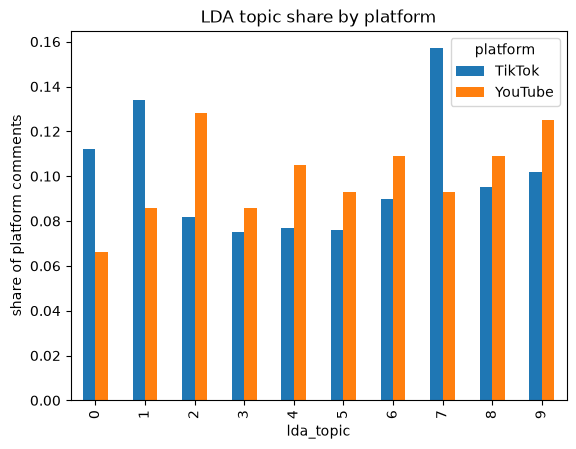

Cosine similarity (TikTok vs YouTube topic mix): 0.9386


In [25]:
ct = pd.crosstab(train_df["lda_topic"], train_df["platform"], normalize="columns").round(3)
print(ct)
ct.plot.bar(title="LDA topic share by platform"); plt.ylabel("share of platform comments"); plt.show()

# cosine similarity between the platforms' topic distributions
from numpy.linalg import norm
a, b = ct["TikTok"].values, ct["YouTube"].values
print("Cosine similarity (TikTok vs YouTube topic mix):", round(float(a @ b / (norm(a) * norm(b))), 4))

## 14. BERTopic (second model)
Uses the raw comment text and a multilingual sentence embedder, which suits short, informal, code-switched comments better than LDA. Topic `-1` holds outliers.

In [ ]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from umap import UMAP
from hdbscan import HDBSCAN

def bt_tokenize(text):
    return [w for w in re.findall(r"[a-z']+", text.lower()) if w not in STOP and len(w) > 2]

emb_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
vectorizer = CountVectorizer(tokenizer=bt_tokenize, token_pattern=None, lowercase=False)

bt = BERTopic(
    embedding_model=emb_model,
    umap_model=UMAP(n_neighbors=10, n_components=5, min_dist=0.0, metric="cosine", random_state=SEED),
    hdbscan_model=HDBSCAN(min_cluster_size=8, metric="euclidean", prediction_data=True),
    vectorizer_model=vectorizer,
    calculate_probabilities=False,
)
train_texts = train_df["original_text"].tolist()
bt_topics, _ = bt.fit_transform(train_texts)
train_df["bt_topic"] = bt_topics

hold_topics, _ = bt.transform(hold_df["original_text"].tolist())
hold_df["bt_topic"] = hold_topics

bt.get_topic_info().head(15)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 278.29it/s]


### BERTopic evaluation (same metrics as LDA)

In [ ]:
bt_dict_tokens = [bt_tokenize(t) for t in train_texts]
bt_dict = Dictionary(bt_dict_tokens)

bt_topic_words = []
for tid in sorted(t for t in set(bt_topics) if t != -1):
    words = [w for w, _ in bt.get_topic(tid)[:10] if w in bt_dict.token2id]
    if len(words) >= 2:
        bt_topic_words.append(words)

bt_cv = CoherenceModel(topics=bt_topic_words, texts=bt_dict_tokens, dictionary=bt_dict, coherence="c_v").get_coherence()
bt_all = [w for t in bt_topic_words for w in t]
bt_div = len(set(bt_all)) / len(bt_all)
outlier_pct = round(100 * (train_df["bt_topic"] == -1).mean(), 1)

print("BERTopic topics (excl. outliers):", len(bt_topic_words))
print("c_v:", round(bt_cv, 4), "| diversity:", round(bt_div, 4), "| outliers %:", outlier_pct)
for i, w in enumerate(bt_topic_words):
    print(f"BT topic {i}:", ", ".join(w))

## 15. Model comparison

In [ ]:
pd.DataFrame({
    "Model": ["LDA", "BERTopic"],
    "Topics": [best_k, len(bt_topic_words)],
    "c_v": [round(cv, 4), round(bt_cv, 4)],
    "Topic diversity": [round(diversity, 4), round(bt_div, 4)],
    "Outlier docs %": [0.0, outlier_pct],
    "Holdout perplexity": [round(perp, 2), "n/a"],
})

## 16. Save outputs

In [ ]:
train_df.drop(columns=["tokens"]).to_csv("topics_train.csv", index=False)
hold_df.drop(columns=["tokens"]).to_csv("topics_holdout.csv", index=False)
topic_table.to_csv("lda_topic_table.csv", index=False)
print("Saved. Reuse train_df['lda_topic'] / ['bt_topic'] for sentiment per topic and similarity measures.")